In [1]:
# Import everything needed for HEBO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hebo.optimizers.hebo import HEBO
from hebo.optimizers.bo import BO
from hebo.design_space.design_space import DesignSpace

import warnings
warnings.filterwarnings("ignore")

# set plotting font to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

Load the `HER_virtual_data.csv` dataset from your laptop to the notebook.

Now, because HEBO is by default *minimizing* functions, we just need to take the negative of the `Target` column as objective values if we want to maximize the target.

So we flip the target values to be `max(targets) - targets` so that they are all nonegative and finding the smallest one is equivalent to finding the largest original target value.

In [27]:
data = pd.read_csv('HER_virtual_data.csv')
true_best_y = data["Target"].max()
data["Target"] = data["Target"].max() - data["Target"]

Define the design space:

In [28]:
params = [
    {'name' : 'AcidRed871_0gL',     'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'L-Cysteine-50gL',    'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'MethyleneB_250mgL',  'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'NaCl-3M',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'NaOH-1M',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'P10-MIX1',           'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'PVP-1wt',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'RhodamineB1_0gL',    'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'SDS-1wt',            'type' : 'num', 'lb' : 0, 'ub' : 5},
    {'name' : 'Sodiumsilicate-1wt', 'type' : 'num', 'lb' : 0, 'ub' : 5},
]

space = DesignSpace().parse(params)

In [ ]:
NUM_ITERATIONS = 200
NUM_SUGGESTIONS_PER_ITERATION = 1


def plot_y_curve(y_raw, label: str, color: str, window_size=8,
                 plot_iter="dots", recover_y=True):

    def smooth_y(y_values):
        """Applies a simple moving average to smooth the y_values."""
        smoothed = np.convolve(y_values, np.ones(window_size)/window_size, mode='valid')
        # add padding using nan
        pad_size = window_size - 1
        pad_left = np.full(pad_size//2, np.nan)
        pad_right = np.full(pad_size - pad_size//2, np.nan)
        smoothed = np.concatenate((pad_left, smoothed, pad_right))
        return smoothed

    if recover_y:  # Plot original objective values (for maximization problems)
        y = -(y_raw - true_best_y).flatten()
        cum_y = np.maximum.accumulate(y)
    else:  # Plot regret
        y = y_raw.flatten()
        cum_y = np.minimum.accumulate(y)
        # use log scale for very small regret
        plt.yscale('log')

    plt.plot(cum_y, '-', linewidth=2, color=color, label=f"{label} Best")
    if plot_iter:
        if plot_iter == "dots":
            plt.plot(y, '.', color=color, alpha=0.5, label=f"{label} Iterations")
        elif plot_iter == "dashed":
            plt.plot(smooth_y(y) if window_size else y,
                     ':', color=color, label=f"{label} Iterations")
        else:
            raise ValueError("plot_iter must be 'dots', 'dashed', or False")


### Optimization with a dynamic Oracle

Because in this case we do not have a real objective function definition, i.e. an *oracle*, we are going to use the dataset directly to show how BO works. 

We randomly split the data into an observation set and a test set, making sure the best point is in the test set.

In particular, we make sure that the best 25% points are not in the training set. 

In [32]:
from sklearn.model_selection import train_test_split

num_best_to_exclude = max(1, int(0.25 * len(data)))
data_best = data.sort_values(by='Target').head(num_best_to_exclude)
indices_to_drop = data_best.index

data_rest = data.drop(indices_to_drop)
data_train, data_test_partial = train_test_split(data_rest, test_size=0.9, random_state=42)
data_test = pd.concat([data_test_partial, data_best])

X_all = data[space.numeric_names]
Y_all = data["Target"].values.reshape(-1, 1)
X_train = data_train[space.numeric_names]
Y_train = data_train["Target"].values.reshape(-1, 1)
X_test = data_test[space.numeric_names]
Y_test = data_test["Target"].values.reshape(-1, 1)

print("#Train data", data_train.shape[0])
print("#Test data", data_test.shape[0])

#Train data 60
#Test data 752


We define a function to find the closest point to the `HEBO` suggestion in the `X_test` dataframe and we take the corresponding value from `Y_test` as objective value.

In [33]:
from scipy.spatial.distance import cdist # Required for efficient distance calculation

def find_nearest_row(df: pd.DataFrame, vector: np.ndarray, feature_cols: list = None) -> int:
    """
    Finds the row in the DataFrame that is closest to the input vector
    using Euclidean distance.
    """
    if not feature_cols:
        feature_cols = df.columns.tolist()

    # 1. Extract feature data from the DataFrame
    df_features = df[feature_cols].values

    # 2. Calculate the distance between the vector and all rows
    # cdist is highly efficient for this calculation
    distances = cdist(df_features, vector.reshape(1, -1), metric='euclidean')

    # 3. Find the index of the minimum distance
    nearest_idx_in_df = np.argmin(distances)

    # 4. Return the full row from the original DataFrame
    return nearest_idx_in_df

In [44]:
hebo = HEBO(space, model_name='gp')
hebo.observe(X_train, Y_train) # observe X_train and Y_train
for i in range(NUM_ITERATIONS):
    rec_x = hebo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # HEBO suggests a new point
    idx = find_nearest_row(X_test, rec_x.values) # find closest point for which we have the true value in X_test
    rec_y = Y_test[idx]
    hebo.observe(rec_x, rec_y)
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {hebo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(hebo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 4, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 8, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 12, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 16, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 20, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 24, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 28, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 32, best_y = 16.19410, y_opt = 0.00000 (true best_y = 11.51001, true y_opt = 27.70410)
Iter 36, best_y = 14.45533, y_opt = 0.00000 (true best_y = 13.24878, true y_opt = 27.70410)
Iter 40, best_y = 14.45533, y_opt = 0.00000 (true best_y = 13.24878, true y_opt = 2

In [59]:
bo = BO(space, model_name='gp')
bo.observe(X_train, Y_train) # observe X_train and Y_train
for i in range(NUM_ITERATIONS):
    rec_x = bo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # BO suggests a new point
    idx = find_nearest_row(X_test, rec_x.values) # find closest point for which we have the true value in X_test
    rec_y = Y_test[idx]
    bo.observe(rec_x, rec_y.reshape(-1, 1))
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {bo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(bo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 4, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 8, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 12, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 16, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 20, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 24, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 28, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 32, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 36, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 27.70410)
Iter 40, best_y = 14.06671, y_opt = 0.00000 (true best_y = 13.63739, true y_opt = 2

In [38]:
rs_log = Y_train.copy().flatten()
for i in range(NUM_ITERATIONS):
    rec_x = space.sample(NUM_SUGGESTIONS_PER_ITERATION) # sample a new point from the search space
    idx = find_nearest_row(X_test, rec_x.values) # find closest point for which we have the true value in X_test
    rec_y = Y_test[idx]
    rs_log = np.concatenate([rs_log, rec_y])
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {rs_log.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(rs_log.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 4, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 8, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 12, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 16, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 20, best_y = 16.84415, y_opt = 0.00000 (true best_y = 10.85996, true y_opt = 27.70410)
Iter 24, best_y = 12.92393, y_opt = 0.00000 (true best_y = 14.78017, true y_opt = 27.70410)
Iter 28, best_y = 12.92393, y_opt = 0.00000 (true best_y = 14.78017, true y_opt = 27.70410)
Iter 32, best_y = 12.92393, y_opt = 0.00000 (true best_y = 14.78017, true y_opt = 27.70410)
Iter 36, best_y = 12.44902, y_opt = 0.00000 (true best_y = 15.25509, true y_opt = 27.70410)
Iter 40, best_y = 12.44902, y_opt = 0.00000 (true best_y = 15.25509, true y_opt = 2

Note that we plot the *Regret* i.e. how close we are getting to the best value in the test set.

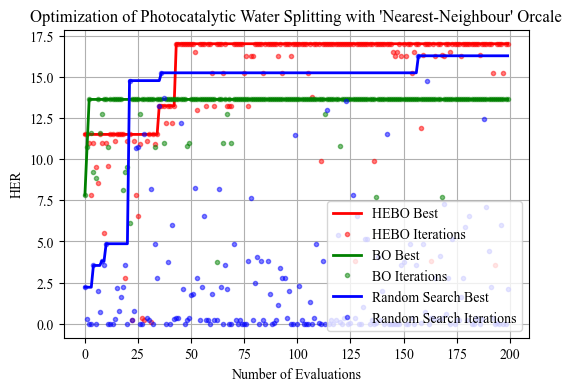

In [63]:
plt.figure(figsize = (6, 4))
T = len(Y_train)
plot_y_curve(hebo.y[T:], label='HEBO', color='red', plot_iter="dots")
plot_y_curve(bo.y[T:], label='BO', color='green', plot_iter="dots")
plot_y_curve(rs_log[T:], label='Random Search', color='blue', plot_iter="dots")
plt.xlabel('Number of Evaluations')
plt.ylabel('HER')
plt.legend(loc='lower right')
plt.grid()
plt.title("Optimization of Photocatalytic Water Splitting with 'Nearest-Neighbour' Orcale")

plt.savefig("plot_HER_nn.pdf")
plt.show()

### Optimization with a learnt Orcale

In this example, we are going to *learn* an oracle function.

In the previous example we were finding the point in the test dataset closest to the new suggested point by the BO algoritm and using its real `Target` value. This has the benefit of using the *true* value associated with the ppoint, but the drawback is that we are not really observing the point that the BO algorithm suggested.

In this following example we make the opposite tradeoff: we learn an oracle, i.e. we learn a model of the `Target` values with a regression model, and we use this *learnt oracle* as our optimization objective. The advantage of this method is that we can now use this oracle to evaluate any point suggested by the BO algorithm. The drawback is that the values are not the *true* values but only *predicted*.

Both examples are methods that are used in practice, the user needs to be aware fo the drawbacks and advantages of both methods but they are both valid ways of comparing optimization algorithms. In the ideal case of course we would like to evaluate the true `Target` value of each new suggested point, but in practice this is not possible because of the prohibitive costs of such evaluations (e.g. requiring wet lab experiments).

In [64]:
from typing import Callable

def construct_oracle(
    data_path: str,
    impl: str = "random_forest"
) -> Callable[[pd.DataFrame], np.ndarray]:

    data = pd.read_csv(data_path)
    target = data["Target"]
    features = data.drop(columns=["Target"])

    # learn a decision tree model as oracle
    if impl == "random_forest":
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(n_estimators=100)
        model.fit(features, target)

        return lambda x: model.predict(x)
    else:
        raise ValueError(f"Unsupported implementation: {impl}")

In [65]:
oracle = construct_oracle(data_path="HER_virtual_data.csv")

In [66]:
hebo = HEBO(space, model_name='gp')
for i in range(NUM_ITERATIONS):
    rec_x = hebo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # HEBO suggests a new point
    rec_y = oracle(rec_x)
    hebo.observe(rec_x, rec_y)
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {hebo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(hebo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 4.57114, y_opt = 0.00000 (true best_y = 23.13296, true y_opt = 27.70410)
Iter 4, best_y = 3.27722, y_opt = 0.00000 (true best_y = 24.42688, true y_opt = 27.70410)
Iter 8, best_y = 1.49461, y_opt = 0.00000 (true best_y = 26.20949, true y_opt = 27.70410)
Iter 12, best_y = 1.01329, y_opt = 0.00000 (true best_y = 26.69081, true y_opt = 27.70410)
Iter 16, best_y = 0.62533, y_opt = 0.00000 (true best_y = 27.07878, true y_opt = 27.70410)
Iter 20, best_y = 0.47787, y_opt = 0.00000 (true best_y = 27.22623, true y_opt = 27.70410)
Iter 24, best_y = 0.47787, y_opt = 0.00000 (true best_y = 27.22623, true y_opt = 27.70410)
Iter 28, best_y = 0.47787, y_opt = 0.00000 (true best_y = 27.22623, true y_opt = 27.70410)
Iter 32, best_y = 0.47787, y_opt = 0.00000 (true best_y = 27.22623, true y_opt = 27.70410)
Iter 36, best_y = 0.47206, y_opt = 0.00000 (true best_y = 27.23204, true y_opt = 27.70410)
Iter 40, best_y = 0.33192, y_opt = 0.00000 (true best_y = 27.37219, true y_opt = 27.70410)
It

In [68]:
bo = BO(space, model_name='gp')
for i in range(NUM_ITERATIONS):
    rec_x = bo.suggest(n_suggestions=NUM_SUGGESTIONS_PER_ITERATION) # BO suggests a new point
    rec_y = oracle(rec_x)
    bo.observe(rec_x, rec_y.reshape(-1, 1))
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {bo.y.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(bo.y.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 5.23756, y_opt = 0.00000 (true best_y = 22.46654, true y_opt = 27.70410)
Iter 4, best_y = 4.60240, y_opt = 0.00000 (true best_y = 23.10171, true y_opt = 27.70410)
Iter 8, best_y = 2.01305, y_opt = 0.00000 (true best_y = 25.69105, true y_opt = 27.70410)
Iter 12, best_y = 1.04406, y_opt = 0.00000 (true best_y = 26.66004, true y_opt = 27.70410)
Iter 16, best_y = 0.83533, y_opt = 0.00000 (true best_y = 26.86877, true y_opt = 27.70410)
Iter 20, best_y = 0.38253, y_opt = 0.00000 (true best_y = 27.32158, true y_opt = 27.70410)
Iter 24, best_y = 0.38253, y_opt = 0.00000 (true best_y = 27.32158, true y_opt = 27.70410)
Iter 28, best_y = 0.38253, y_opt = 0.00000 (true best_y = 27.32158, true y_opt = 27.70410)
Iter 32, best_y = 0.29278, y_opt = 0.00000 (true best_y = 27.41133, true y_opt = 27.70410)
Iter 36, best_y = 0.28949, y_opt = 0.00000 (true best_y = 27.41462, true y_opt = 27.70410)
Iter 40, best_y = 0.25832, y_opt = 0.00000 (true best_y = 27.44578, true y_opt = 27.70410)
It

In [69]:
rs_log = np.array([], dtype=float)
for i in range(NUM_ITERATIONS):
    rec_x = space.sample(NUM_SUGGESTIONS_PER_ITERATION) # sample a new point from the search space
    rec_y = oracle(rec_x)
    rs_log = np.concatenate([rs_log, rec_y])
    if i % 4 == 0:
        print(f'Iter {i}, best_y = {rs_log.min():.5f}, y_opt = {Y_test.min():.5f} '
              f'(true best_y = {-(rs_log.min()-true_best_y):.5f}, true y_opt = {true_best_y:.5f})')

Iter 0, best_y = 5.40550, y_opt = 0.00000 (true best_y = 22.29861, true y_opt = 27.70410)
Iter 4, best_y = 2.89481, y_opt = 0.00000 (true best_y = 24.80930, true y_opt = 27.70410)
Iter 8, best_y = 2.81232, y_opt = 0.00000 (true best_y = 24.89178, true y_opt = 27.70410)
Iter 12, best_y = 2.81232, y_opt = 0.00000 (true best_y = 24.89178, true y_opt = 27.70410)
Iter 16, best_y = 2.04709, y_opt = 0.00000 (true best_y = 25.65701, true y_opt = 27.70410)
Iter 20, best_y = 0.62539, y_opt = 0.00000 (true best_y = 27.07871, true y_opt = 27.70410)
Iter 24, best_y = 0.62539, y_opt = 0.00000 (true best_y = 27.07871, true y_opt = 27.70410)
Iter 28, best_y = 0.62539, y_opt = 0.00000 (true best_y = 27.07871, true y_opt = 27.70410)
Iter 32, best_y = 0.62539, y_opt = 0.00000 (true best_y = 27.07871, true y_opt = 27.70410)
Iter 36, best_y = 0.62539, y_opt = 0.00000 (true best_y = 27.07871, true y_opt = 27.70410)
Iter 40, best_y = 0.62539, y_opt = 0.00000 (true best_y = 27.07871, true y_opt = 27.70410)
It

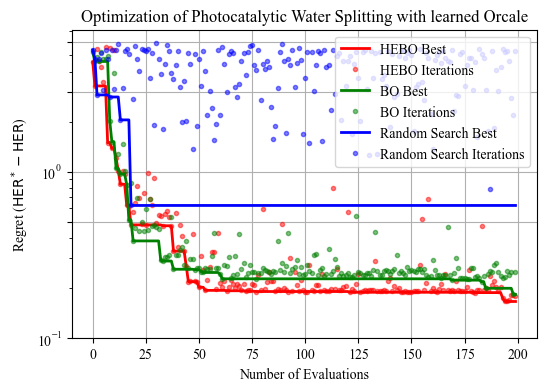

In [ ]:
plt.figure(figsize = (6, 4))
plot_y_curve(hebo.y, label='HEBO', color='red', recover_y=False)
plot_y_curve(bo.y, label='BO', color='green', recover_y=False)
plot_y_curve(rs_log, label='Random Search', color='blue', recover_y=False)
plt.xlabel('Number of Evaluations')
plt.ylabel('Regret ($\mathrm{HER}^* - \mathrm{HER}$)')
plt.yticks([6, 3, 1, 0.5, 0.1])
plt.legend(loc='upper right')
plt.grid()
plt.title("Optimization of Photocatalytic Water Splitting with learned Orcale")
plt.savefig("plot_HER_learned.pdf", dpi=300)
plt.show()